In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import transforms as T

import pytorch_lightning as pl

from torchmetrics.classification import Accuracy
from torchmetrics.aggregation import MeanMetric
from torchvision.datasets import MNIST

from datetime import datetime


from xaikd import datasets, utils, attributors, jacobian

from tqdm.notebook import tqdm
from xaikd.bases import PRCAReconGreedy, PRCASignAlignGreedy, PRCASignAlignGreedyV2


from zennit.attribution import Gradient
from zennit.composites import EpsilonGammaBox

from xaikd.bases import pcalookahead



import numpy as np
import numpy.typing as npt

import os

import typing

from collections import OrderedDict

In [2]:
!nproc

16


In [3]:
DEVICE = utils.get_device()
DEVICE

'cuda'

In [4]:
NUM_WORKERS = 16

DATA_SIZE = 0.1


In [5]:
ds_train = datasets.MultiTaskEMNISTFashionMNIST(
    train=True,
    root="../../datasets",
    transform=T.Compose(
        [
            T.ToTensor(),
            T.Normalize(
                0.5,
                0.5,
            ),
        ]
    )
)

ds_val = datasets.MultiTaskEMNISTFashionMNIST(
    train=False,
    root="../../datasets",
    transform=T.Compose(
        [
            T.ToTensor(),
            T.Normalize(
                0.5,
                0.5,
            ),
        ]
    )
)

In [6]:
TASK_NUM_CLASSES = ds_train.num_classes

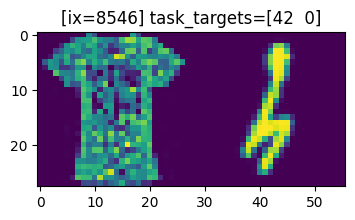

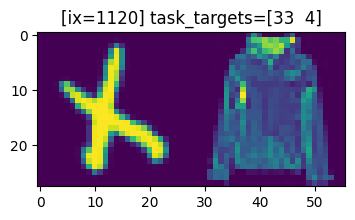

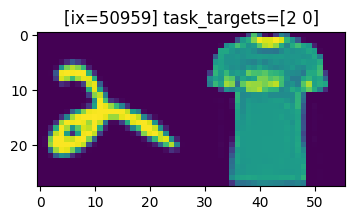

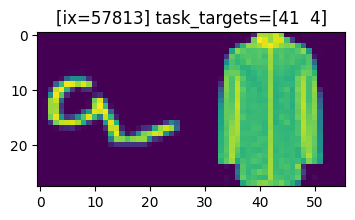

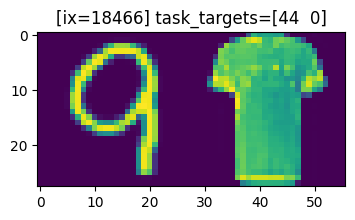

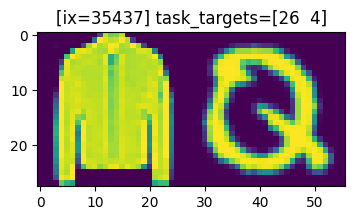

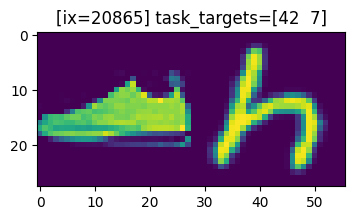

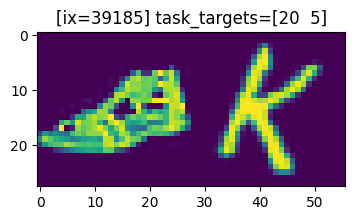

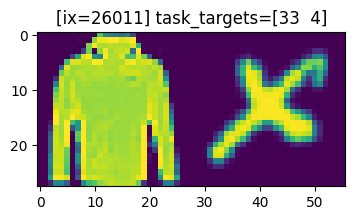

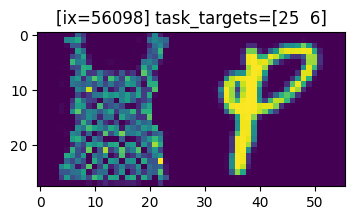

In [7]:
def ano():

    for ix in np.random.permutation(60000)[:10]:
        
        x, y = ds_train[ix]
    
        plt.figure(figsize=(2*2, 2))
        plt.imshow(x.squeeze())
        plt.title(f"[ix={ix}] task_targets={y}")
ano()

# Construct Model and Train

In [8]:
class CNN(nn.Module):
    def __init__(self, num_classes=10, d=256):
        super().__init__()
        self.conv1 = nn.Conv2d(kernel_size=3, out_channels=d, in_channels=1)
        self.act1 = nn.ReLU()
        self.max1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(kernel_size=3, out_channels=d, in_channels=d)
        self.act2 = nn.ReLU()
        self.max2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(kernel_size=3, out_channels=d, in_channels=d)
        self.act3 = nn.ReLU()
        self.avgpool = nn.AdaptiveAvgPool2d(output_size=1)
        
        self.fc_task_1 = nn.Linear(d, TASK_NUM_CLASSES[0])
        self.fc_task_2 = nn.Linear(d, TASK_NUM_CLASSES[1])

    def forward(self, x):
        x = self.act1(self.conv1(x))
        x = self.max1(x)
        
        x = self.act2(self.conv2(x))
        x = self.max2(x)
        
        x = self.act3(self.conv3(x))
        
        x = self.avgpool(x)
        x = torch.flatten(x, start_dim=1)
        out_task_1 = self.fc_task_1(x)
        out_task_2 = self.fc_task_2(x)

        return out_task_1, out_task_2
    
def ano():
    
    out = CNN()(torch.randn(7, 1, 28, 28*2))
    
    print(f"santity check")
ano()

santity check


In [9]:
from torchvision.models.resnet import resnet18
from torch import nn

In [10]:
resnet18(num_classes=10);

In [11]:
class ModelWrapper(pl.LightningModule):
    def __init__(self, encoder, lr=1e-3, weight_decay=0.0):
        super().__init__()

        self.encoder = encoder
        
        self.weight_decay = weight_decay
        self.lr = lr

    def forward(self, x):
        embedding = self.encoder(x)
        return embedding

    def configure_optimizers(self):

        optimizer = torch.optim.Adam(
            self.parameters(), lr=self.lr, 
            # momentum=0.0, weight_decay=self.weight_decay
        )

        return optimizer

    def compute_metric(self, batch, prefix):

        x, y = batch

        arr_logits = self.encoder(x)

        loss = 0
        for tidx in range(2):
            y_task = y[:, tidx]
            logits_task = arr_logits[tidx]
            loss += 0.5*F.cross_entropy(
                logits_task, 
                y_task
            )

        return loss

    def training_step(self, train_batch, batch_idx):

        loss = self.compute_metric(train_batch, "train")

        self.log("train_loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def summary_metric(self, prefix):

        metric = self.metrics[prefix]
        value = metric.compute()

        self.log(f"{prefix}_acc", value)

        metric.reset()

In [12]:
pl.seed_everything(1)


dl_train_noshuffle = DataLoader(
    random_split(ds_train, [DATA_SIZE, 1-DATA_SIZE])[0],
    batch_size=64,
    num_workers=NUM_WORKERS,
    # pin_memory=True,
    shuffle=False,
)

dl_test = DataLoader(
    ds_val,
    batch_size=64,
    num_workers=NUM_WORKERS,
    # pin_memory=True,
    shuffle=False,
)

dl_train = DataLoader(
    ds_train,
    batch_size=64,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True
)


model  = CNN()

trainer = pl.Trainer(
    max_epochs=50,
    accelerator=DEVICE,
    default_root_dir="/tmp"
)

# trainer.fit(ModelWrapper(model), dl_train, dl_test)
# torch.save(model.state_dict(), "./model-cnn-multinist.pth")

model.load_state_dict(
    torch.load("./model-cnn-multinist.pth")
)
model = model.to(DEVICE)

model.eval()

[rank: 0] Global seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


CNN(
  (conv1): Conv2d(1, 256, kernel_size=(3, 3), stride=(1, 1))
  (act1): ReLU()
  (max1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
  (act2): ReLU()
  (max2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
  (act3): ReLU()
  (avgpool): AdaptiveAvgPool2d(output_size=1)
  (fc_task_1): Linear(in_features=256, out_features=47, bias=True)
  (fc_task_2): Linear(in_features=256, out_features=10, bias=True)
)

In [13]:
def estimate_task_acc(model, dl, task_id, verbose=False):
    metric = Accuracy(task="multiclass", num_classes=TASK_NUM_CLASSES[task_id])
    metric_xent = MeanMetric()
    for x, y in tqdm(dl, disable=not verbose):
        task_logit = model(x.to(DEVICE))[task_id].detach().cpu()
        task_target = y[:, task_id]
        metric.update(task_logit, task_target)
        metric_xent.update(F.cross_entropy(task_logit, task_target))
    acc =  float(metric.compute())
    xent = float(metric_xent.compute())
    return acc, xent
def compute_accs():
    
    stats = dict()
    
    for tidx in tqdm(range(2)):
        
        for label, dl in [
            # ("train", dl_train_noshuffle),
            ("test", dl_test)
        ]:            
            stats[f"acc_task_{tidx}_{label}"], stats[f"xent_task_{tidx}_{label}"] = estimate_task_acc(model, dl, tidx)
    
    return stats

ref_stats = compute_accs()
ref_stats

  0%|          | 0/2 [00:00<?, ?it/s]

{'acc_task_0_test': 0.8428000211715698,
 'xent_task_0_test': 0.5066717267036438,
 'acc_task_1_test': 0.8921999931335449,
 'xent_task_1_test': 0.33956974744796753}

# Getting Jacobian

In [14]:
ARR_LAYERS = ["max1", "max2", "act3"]

ARR_LAYERS

['max1', 'max2', 'act3']

In [15]:
def subsample_along_axes(
    x: torch.Tensor, 
    rng: np.random.Generator,
    axes: typing.List[int], 
    num_locations_per_axis: typing.List[int],
):

    nb = x.shape[0]
    arr_locations = []
    for axis, num_location in zip(axes, num_locations_per_axis):
        arr_locations.append(
            utils.ndarray_sampling.get_random_permutations(
                rng=rng,
                n=nb,
                total=x.shape[axis],
                num_chosen=num_location
            )
        )
    return utils.ndarray_sampling.gather_locations_along_axes(
        x=x,
        axes=axes,
        arr_selected_locations=arr_locations
    )

def sanity_check():

    x = torch.randn((32, 5+1, 128, 5, 12))

    rng = np.random.default_rng(seed=1)
    subsample_along_axes(
        x,
        rng,
        axes=[-1, -2], 
        num_locations_per_axis=[4, 4]
    )
    print("sanity check: passed")
sanity_check()

sanity check: passed


In [16]:
def extract_activation_jacobian(
    model: nn.Module,
    layer: str,
    dataloader: DataLoader,
    task_id: int,
    rng: np.random.Generator,
    device="cpu",
    num_of_selected_spatial_locations=4,
    strict_mode=False,
    verbose=False,
):
    arr_act = []
    arr_ctx = []


    try:
        module, hook = utils.interceptor.attach_hook_intercept_layer_output(
            model, layer, should_retain_grad=True, detach_output=False
        )
        
        for batch in tqdm(dataloader, desc=f"[layer={layer}] extract act ctx"):
            x, y = batch
            x = x.to(device)
            x.requires_grad_(True)

            
            logits = model(x)[task_id]

            act = utils.interceptor.get_output(module)
            
            J = jacobian.compute(logits, act)

            size = act.shape[1:]
            nb, d_out = logits.shape

            assert len(act.shape) == 4
            assert len(J.shape) == 5
            assert J.shape == (nb, d_out, *size)
            
            act_J = np.concatenate(
                [
                    act.unsqueeze(1).detach().cpu().numpy(),
                    J.detach().cpu().numpy(),
                ],
                axis=1
            )

            assert act_J.shape == (nb, d_out + 1, *size)

            subsampled_act_J = subsample_along_axes(
                x=act_J,
                axes=[-1, -2], # spatial dimensions,
                rng=rng,
                num_locations_per_axis=[num_of_selected_spatial_locations] * 2
            )

            subsampled_act = subsampled_act_J[:, 0, :, :, :]
            subsampled_J = subsampled_act_J[:, 1:, :, :, :]
            
            arr_act.append(subsampled_act)
            arr_ctx.append(subsampled_J)

    finally:
        hook.remove()

    if verbose:
        print(f"[layer={layer}]: output-dims={size}")

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)

    if verbose:
        print(f" > arr_act.shape={arr_act.shape}")
        print(f" > arr_ctx.shape={arr_ctx.shape}")
    
    return arr_act, arr_ctx

def sanity_check():

    rng = np.random.default_rng(seed=1)
    
    extract_activation_jacobian(
        model=model, 
        layer="max2", 
        dataloader=dl_train_noshuffle, 
        task_id=1, 
        rng=rng,
        device=DEVICE,
        verbose=True
    )
    print("Sanity Check: passed!")
    
sanity_check()

[layer=max2] extract act ctx:   0%|          | 0/94 [00:00<?, ?it/s]

[layer=max2]: output-dims=torch.Size([256, 5, 12])
 > arr_act.shape=(6000, 256, 4, 4)
 > arr_ctx.shape=(6000, 10, 256, 4, 4)
Sanity Check: passed!


## Model-Splitting Functionalities for PCA-LH

In [17]:
def split_model_for_task(model, layer, task_id):

    arr_name_layers = list(model.named_children())

    layer_names = list(map(lambda t: t[0], arr_name_layers))
    layer_ix = layer_names.index(layer)
    avgpool_ix = layer_names.index("avgpool")


    task_module_name = f"fc_task_{task_id+1}"
    
    task_module = getattr(model, task_module_name)

    first_module = nn.Sequential(OrderedDict(
        arr_name_layers[:layer_ix+1]
    ))
    second_module = nn.Sequential(OrderedDict(
        arr_name_layers[layer_ix+1:avgpool_ix+1] 
        + [
            ("flatten", nn.Flatten(start_dim=1)),
            (task_module_name, task_module)
        ]
    ))
    
    return first_module, second_module

@torch.no_grad()
def ano():


    trng = torch.Generator()
    trng.manual_seed(1)
    
    x = torch.randn(10, 1, 28, 56, generator=trng).to(DEVICE)
    
        
    for task_id in [0, 1]:
        for layer in ARR_LAYERS:
            m1, m2 = split_model_for_task(model, layer, task_id)

            actual = m2(m1(x)).cpu().numpy()
            expected = model(x)[task_id].cpu().numpy()
            np.testing.assert_allclose(
                actual,
                expected
            )
            print(f"sanity check: task_id={task_id} layer={layer} passed!")
ano()

sanity check: task_id=0 layer=max1 passed!
sanity check: task_id=0 layer=max2 passed!
sanity check: task_id=0 layer=act3 passed!
sanity check: task_id=1 layer=max1 passed!
sanity check: task_id=1 layer=max2 passed!
sanity check: task_id=1 layer=act3 passed!


# Basis Construction

In [18]:
def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvecs

## Baseline

In [40]:
def compute_act_cov(x):
    nb, d_in, h, w = x.shape

    x = np.transpose(x, [1, 0, 2, 3]).reshape((d_in, nb*h*w))

    cov = x @ x.T 

    return cov / nb


def compute_grad_cov(x):
    nb, d_out, d_in, h, w = x.shape

    x = np.transpose(x, [2, 0, 1, 3, 4]).reshape((d_in, d_out * nb*h*w))

    cov = x @ x.T
    return cov / nb
    

def compute_actgrad_cov(a, c):
    nb, d_in, h, w = a.shape

    assert c.shape[0] == nb
    assert c.shape[2:] == (d_in, h, w)

    a = np.transpose(a, [1, 0, 2, 3]).reshape((d_in, nb*h*w))

    # sum over output dimensions
    c = c.sum(axis=1)
    np.testing.assert_allclose(c.shape, (nb, d_in, h, w))
    c = np.transpose(c, [1, 0, 2, 3]).reshape((d_in, nb*h*w))
    
    ac = a @ c.T 
    ca = c @ a.T

    return (ac + ca) / nb


def sanity_check():


    nb = 32
    d_in = 16
    d_out = 10
    h, w = 8, 7
    arr_act = torch.randn((nb, d_in, h, w)).numpy()
    arr_ctx = torch.randn((nb, d_out, d_in, h, w)).numpy()

    
    cov_act = compute_act_cov(arr_act)

    expected_cov_act = np.transpose(arr_act, [1, 0, 2, 3]).reshape((d_in, h*w*nb))
    expected_cov_act = expected_cov_act @ expected_cov_act.T / nb
    np.testing.assert_allclose(
        cov_act,
        expected_cov_act,
        atol=1e-3
    )

    cov_grad = compute_grad_cov(arr_ctx)
    expected_cov_grad = np.transpose(arr_ctx, [2, 0, 1, 3, 4]).reshape((16, h*w*nb*d_out))
    expected_cov_grad = expected_cov_grad @ expected_cov_grad.T / nb
    np.testing.assert_allclose(
        cov_grad,
        expected_cov_grad,
        atol=1e-3
    )

    cov_actgrad = compute_actgrad_cov(arr_act, arr_ctx)

    expected_cov_actgrad = np.zeros((d_in, d_in))
    A = np.transpose(arr_act, [1, 0, 2, 3]).reshape((d_in, h*w*nb)).T
    for i in range(d_out):
        C = np.transpose(
            arr_ctx[:, i, :, :, :],
            [1, 0, 2, 3]
        ).reshape((d_in, h*w*nb)).T

        expected_cov_actgrad += (A.T @ C + C.T @ A) / nb
        
    np.testing.assert_allclose(
        cov_actgrad,
        expected_cov_actgrad,
        atol=1e-3
    )
    print("sanity-check: passed")


sanity_check()

sanity-check: passed


In [42]:
class BasisInterface:
    def get_Uk(self, k: int) -> npt.NDArray:
        raise NotImplementedError()   

class PCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        cov = compute_act_cov(arr_act)
        self.U = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class GradPCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        cov = compute_grad_cov(arr_ctx)
        self.U = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]


class PRCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        cov = compute_actgrad_cov(arr_act, arr_ctx)
        self.U = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class PRCASortAbs(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        cov = compute_actgrad_cov(arr_act, arr_ctx)
        self.U = _solve_eigvecs(cov, sort_func=np.abs)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

## PCALookAhead

In [21]:
class PCALookAhead(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        self.arr_act = arr_act
        self.arr_ctx = arr_ctx

        self.layer = layer
        self.task_id = task_id
        self.is_slow = True
        
    def get_Uk(self, k: int):
        first_module, second_module = split_model_for_task(
            model,
            layer=self.layer,
            task_id=self.task_id
        ) 

        U = pcalookahead.fit_v2(
            first_module=first_module,
            second_module=second_module,
            dataloader=dl_train,
            Uinit=PCABasis(arr_act=self.arr_act, arr_ctx=self.arr_ctx).get_Uk(k),
            k=k,
            epochs=5,
            verbose=True,
            device=DEVICE
        )
        np.testing.assert_allclose(
            U.T @ U,
            np.eye(k),
            atol=1e-5
        )
        return U

## PRCASignAlignGreedy

In [22]:
# class PRCASignAlignGreedyV3:
#     @torch.no_grad()
#     def fit(
#         self, arr_act: npt.NDArray, arr_ctx: npt.NDArray, device="cpu"
#     ) -> npt.NDArray:
#         n, d = arr_act.shape

#         I = torch.eye(d).to(device)

#         arr_act: torch.Tensor = torch.from_numpy(arr_act).to(device)
#         arr_ctx: torch.Tensor = torch.from_numpy(arr_ctx).to(device)

#         U_prev = self._solve_objective(arr_act, arr_ctx)
#         assert U_prev.shape == (d, 1)

#         for k in tqdm(range(1, d), desc="PRCASignGreedyV2"):

#             U_comp = I - U_prev @ U_prev.T

#             arr_act_on_U_comp = arr_act @ U_comp
#             arr_ctx_on_U_comp = arr_ctx @ U_comp

#             u_star = self._solve_objective(arr_act_on_U_comp, arr_ctx_on_U_comp)

#             # stacking prev results and the eigenvector
#             # shape : (d, k+1)
#             U_prev_and_k = torch.hstack([U_prev, u_star])

#             # performing gram-schmidt
#             U_prev, _ = torch.linalg.qr(U_prev_and_k)

#             assert U_prev.shape == (d, k + 1)

#             # sanity check
#             Vk = U_prev.detach().cpu().numpy()
#             np.testing.assert_allclose(Vk.T @ Vk, np.eye(k + 1), atol=1e-3)

#         U = U_prev.detach().cpu().numpy()

#         # sanity_check
#         np.testing.assert_allclose(U.T @ U, np.eye(d), atol=1e-3)

#         return U

#     def _solve_objective(
#         self, arr_act: torch.Tensor, arr_ctx: torch.Tensor
#     ) -> torch.Tensor:

#         arr_rel = (arr_act * arr_ctx).sum(dim=1, keepdim=True)

#         arr_act_with_rel = arr_act * torch.sign(arr_rel)

#         cov = arr_act_with_rel.T @ arr_ctx + arr_ctx.T @ arr_act_with_rel

#         _, eigvecs = torch.linalg.eigh(cov)

#         return eigvecs[:, -1].reshape((-1, 1))

# @register_basis()
# class PRCASignAlignGreedyV3Basis(BasisInterface):
#     def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
#         cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
#         self.U =   PRCASignAlignGreedyV3().fit(
#             arr_act=arr_act, arr_ctx=arr_ctx, device=DEVICE
#         )
        
#     def get_Uk(self, k: int):
#         return self.U[:, :k]


##  PRCAReconGreedy

In [23]:
# @register_basis()
# class PRCAReconGreedyBasis(BasisInterface):
#     def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
#         cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
#         self.U =   PRCAReconGreedy().fit(
#             activation=arr_act, context=arr_ctx, device=DEVICE
#         )
        
#     def get_Uk(self, k: int):
#         return self.U[:, :k]


## PRCARecon (non greedy)

In [62]:
def compute_Jresidue(J, residue):

    return torch.einsum("ndkwh,nkwh->nd", J, residue)
    
def sanity_check():

    residue = torch.randn((32, 16, 7, 5))
    J = torch.randn((32, 10, 16, 7, 5))
    
    actual = compute_Jresidue(J, residue)

    expected = np.zeros((32, 10))

    residue = np.transpose(residue.detach().numpy(), [1, 0, 2, 3])
    for i in range(10):
        Ji = np.transpose(J[:, i].detach().numpy(), [1, 0, 2, 3])

        Jresidue = (residue * Ji).sum(axis=0)
        # sum over spatial dimensions
        expected[:, i] = Jresidue.sum(axis=-2).sum(axis=-1)
        
    np.testing.assert_allclose(actual.detach().numpy(), expected, atol=1e-3)
    
sanity_check()

In [65]:
class PRCAReconNonGreedy:
    def __init__(self, task_id, layer):
        self.task_id = task_id
        self.layer = layer
    def fit(
        self, arr_act: npt.NDArray, arr_ctx: npt.NDArray, k: int,  U_init=None, device="cpu",
    ) -> npt.NDArray:
        n, d, _, _ = arr_act.shape

        assert arr_ctx.shape[2:] == arr_act.shape[1:]
        assert arr_ctx.shape[0] == n
        
        
        lr = 1e-3
        epochs = 5000
                

        arr_act = arr_act / ((np.mean(arr_act**2) ** (1 / 2)) * (d ** (1 / 4)))
        arr_ctx = arr_ctx / ((np.mean(arr_ctx**2) ** (1 / 2)) * (d ** (1 / 4)))
        
        arr_act: torch.Tensor = torch.from_numpy(arr_act).to(device)
        arr_ctx: torch.Tensor = torch.from_numpy(arr_ctx).to(device)


        linear_layer = torch.nn.Linear(k, d, bias=False)
        trng = torch.Generator()
        trng.manual_seed(1)
        if U_init is None:
            
            U_init = torch.randn((k, d), generator=trng)
        else:
            U_init = torch.from_numpy(U_init.T)
            
        linear_layer.weight = torch.nn.Parameter(U_init)
    
        ortho_layer = torch.nn.utils.parametrizations.orthogonal(linear_layer).to(device)
        assert ortho_layer.weight.shape == (k, d)
        
        optimizer = torch.optim.Adam(ortho_layer.parameters(), lr=lr)

        pgb = tqdm(range(epochs), desc=f"{self.__class__.__name__} (k={k})")
        for epoch in pgb:
            optimizer.zero_grad()
            
            # shape: (k, d)
            U = ortho_layer.weight

            arr_act_projected = F.conv2d(
                arr_act,
                (U.T @ U).unsqueeze(2).unsqueeze(3)
            )

            residue = arr_act_projected - arr_act

            Jresidue = torch.einsum(
                "ndkwh,nkwh->nd",
                arr_ctx,
                residue
            )
            
            loss = (Jresidue ** 2).sum(dim=1).mean()
            
            loss.backward()
        
            optimizer.step()

            loss = loss.detach().cpu().numpy()
                
            pgb.set_description_str(f"{self.__class__.__name__} (k={k}) loss={loss:.4e}")
            
        U =  ortho_layer.weight.T.detach().cpu().numpy()
        
        # sanity_check
        np.testing.assert_allclose(U.T @ U, np.eye(k), atol=1e-4)

        return U


class PRCARecon(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        self.arr_act = arr_act
        self.arr_ctx = arr_ctx

        self.layer = layer
        self.task_id = task_id
        self.is_slow = True
        
    def get_Uk(self, k: int):

        return PRCAReconNonGreedy(
            layer=self.layer,
            task_id=self.task_id
        ).fit(
            self.arr_act, self.arr_ctx, 
            k=k,
            U_init=GradPCA(arr_act=self.arr_act, arr_ctx=self.arr_ctx).get_Uk(k),
            device=DEVICE
        )

In [69]:
def construct_fh(Uk):
    def fh(mod, inp, outp):
        return F.conv2d(
            outp,
            (Uk@Uk.T).unsqueeze(2).unsqueeze(3)
        )
    return fh

def compute_task_acc_at_k(
    model, layer, task_id, 
    arr_ks, arr_ks_for_slow_learners,
    arr_basis_names=[PCA, GradPCA],
    base_output_dir="./artifacts/multinist-jocabian",
):

    rng = np.random.default_rng(seed=1)
    
    arr_act, arr_ctx =   extract_activation_jacobian(
        model=model, 
        layer=layer,
        dataloader=dl_train_noshuffle, 
        task_id=task_id, 
        rng=rng,
        device=DEVICE,
        verbose=False
    )

    arr_ks = sorted(list(set(arr_ks + arr_ks_for_slow_learners)))
    
    module = getattr(model, layer)

    suffix = "relevance-grad"
    output_path = f"{base_output_dir}/task-{task_id}/{layer}/{suffix}"
    os.makedirs(output_path, exist_ok=True)

    arr_dfs = []

    for basis_class in arr_basis_names:
        basis: BasisInterface = basis_class(
            arr_act=arr_act, 
            arr_ctx=arr_ctx,
            layer=layer,
            task_id=task_id
        )

        basis_name = basis.__class__.__name__
        
        arr_stat_rows = []

        for k in tqdm(
            arr_ks_for_slow_learners if hasattr(basis, "is_slow") else arr_ks, 
            desc=f"[{basis_name:<20s}] Estimating Performance"
        ):

            Uk = basis.get_Uk(k=k)

            # arr_recon_act = (arr_act @ Uk) @ Uk.T

            # recon_err = np.linalg.norm(arr_act - arr_recon_act, axis=1).mean()
            # projected_rel = ((arr_act @ Uk) * (arr_ctx @ Uk)).sum(axis=1)
            # rel_recon_err = ((rel - projected_rel) **2).mean()
            # assert rel.shape == projected_rel.shape == (rel.shape[0], )
            # perc_sign_align = (np.sign(rel) * np.sign(projected_rel)).mean()
            
            Uk = torch.from_numpy(Uk).to(DEVICE)
            row = dict(
                layer=layer,
                task_id=task_id, 
                k=k, 
                basis_name=basis_name,
            #     recon_err=recon_err,
            #     rel_recon_err=rel_recon_err,
            #     perc_sign_align=perc_sign_align,
            )
            try:
                hook = module.register_forward_hook(construct_fh(Uk))
                
                for label, dl in [
                    ("test", dl_test)
                ]:
                    row[f"acc_{label}"], row[f"xent_{label}"] = estimate_task_acc(model, dl, task_id)
                
            finally:
                hook.remove()
            arr_stat_rows.append(row)
            
        df = pd.DataFrame(arr_stat_rows)
        df.to_csv(
            f"{output_path}/{basis_name}.csv",
            index=False
        )

        arr_dfs.append(df)

    df = pd.concat(arr_dfs).sort_values(by=["k", "acc_test"], ascending=[True, False])
    print(f"Checking results at {output_path}")
    return df

    

compute_task_acc_at_k(
    model, layer="act3", 
    task_id=1, 
    arr_ks=[5, 10],
    arr_ks_for_slow_learners=[5, 10, 15],
    base_output_dir="./tmp",
    arr_basis_names=[ 
        PRCARecon,
        
        PCA,
        GradPCA,
        # PRCA,
        PRCASortAbs,
     ]
)

[layer=act3] extract act ctx:   0%|          | 0/94 [00:00<?, ?it/s]

[PRCARecon           ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

PRCAReconNonGreedy (k=5):   0%|          | 0/5000 [00:00<?, ?it/s]

PRCAReconNonGreedy (k=10):   0%|          | 0/5000 [00:00<?, ?it/s]

PRCAReconNonGreedy (k=15):   0%|          | 0/5000 [00:00<?, ?it/s]

[PCA                 ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

[GradPCA             ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

[PRCASortAbs         ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

Checking results at ./tmp/task-1/act3/relevance-grad


,layer,task_id,k,basis_name,acc_test,xent_test
0,act3,1,5,PRCARecon,0.6442,0.910253
0,act3,1,5,GradPCA,0.6349,1.192067
0,act3,1,5,PRCASortAbs,0.2075,3.960056
0,act3,1,5,PCA,0.1000,3.331012
1,act3,1,10,PRCARecon,0.8922,0.339679
1,act3,1,10,GradPCA,0.8921,0.339575
1,act3,1,10,PRCASortAbs,0.2404,3.426139
1,act3,1,10,PCA,0.1108,3.628950
2,act3,1,15,PRCARecon,0.8922,0.339617
2,act3,1,15,GradPCA,0.8922,0.339565


In [70]:

compute_task_acc_at_k(
    model, layer="max2", 
    task_id=1, 
    arr_ks=[5, 10],
    arr_ks_for_slow_learners=[5, 10, 15],
    base_output_dir="./tmp",
    arr_basis_names=[ 
        PRCARecon,
        
        PCA,
        GradPCA,
        # PRCA,
        PRCASortAbs,
     ]
)

[layer=max2] extract act ctx:   0%|          | 0/94 [00:00<?, ?it/s]

[PRCARecon           ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

PRCAReconNonGreedy (k=5):   0%|          | 0/5000 [00:00<?, ?it/s]

PRCAReconNonGreedy (k=10):   0%|          | 0/5000 [00:00<?, ?it/s]

PRCAReconNonGreedy (k=15):   0%|          | 0/5000 [00:00<?, ?it/s]

[PCA                 ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

[GradPCA             ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

[PRCASortAbs         ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

Checking results at ./tmp/task-1/max2/relevance-grad


,layer,task_id,k,basis_name,acc_test,xent_test
0,max2,1,5,GradPCA,0.6696,1.106088
0,max2,1,5,PRCASortAbs,0.5855,1.890019
0,max2,1,5,PRCARecon,0.5736,2.423849
0,max2,1,5,PCA,0.2546,2.738009
1,max2,1,10,PRCARecon,0.8548,0.471511
1,max2,1,10,PCA,0.8038,0.675962
1,max2,1,10,PRCASortAbs,0.7843,0.817638
1,max2,1,10,GradPCA,0.7429,1.131975
2,max2,1,15,PRCARecon,0.8880,0.356033
2,max2,1,15,PCA,0.8790,0.376234


In [71]:

compute_task_acc_at_k(
    model, layer="max1", 
    task_id=1, 
    arr_ks=[5, 10],
    arr_ks_for_slow_learners=[5, 10, 15],
    base_output_dir="./tmp",
    arr_basis_names=[ 
        PRCARecon,
        
        PCA,
        GradPCA,
        # PRCA,
        PRCASortAbs,
     ]
)

[layer=max1] extract act ctx:   0%|          | 0/94 [00:00<?, ?it/s]

[PRCARecon           ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

PRCAReconNonGreedy (k=5):   0%|          | 0/5000 [00:00<?, ?it/s]

PRCAReconNonGreedy (k=10):   0%|          | 0/5000 [00:00<?, ?it/s]

PRCAReconNonGreedy (k=15):   0%|          | 0/5000 [00:00<?, ?it/s]

[PCA                 ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

[GradPCA             ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

[PRCASortAbs         ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

Checking results at ./tmp/task-1/max1/relevance-grad


,layer,task_id,k,basis_name,acc_test,xent_test
0,max1,1,5,PRCARecon,0.8067,0.619200
0,max1,1,5,PCA,0.7739,0.639569
0,max1,1,5,PRCASortAbs,0.6974,0.967098
0,max1,1,5,GradPCA,0.3227,4.173177
1,max1,1,10,PRCARecon,0.8812,0.359533
1,max1,1,10,PRCASortAbs,0.8506,0.474425
1,max1,1,10,PCA,0.8309,0.496218
1,max1,1,10,GradPCA,0.7389,0.937617
2,max1,1,15,PRCARecon,0.8843,0.354975
2,max1,1,15,PCA,0.8814,0.362827


# Computing Results

In [72]:
def get_dims(layer):
    return {
        "max1": 256,
        "max2": 256,
        "act3": 256,
    }[layer]

In [74]:

for layer in  tqdm(["act3", "max2", "max1"]):
    d = get_dims(layer)

    arr_ks = np.linspace(1, d // 4, 10).astype(int).tolist() + [d]
    for task_id in [0, 1]:

        compute_task_acc_at_k(
            model, layer=layer, 
            task_id=task_id, 
            arr_ks=arr_ks,
            arr_ks_for_slow_learners=arr_ks,
            arr_basis_names=[ 
                PRCARecon,
                PCA,
                GradPCA,
                PRCASortAbs,
            ]
    )

  0%|          | 0/3 [00:00<?, ?it/s]

[layer=act3] extract act ctx:   0%|          | 0/94 [00:00<?, ?it/s]

[PRCARecon           ] Estimating Performance:   0%|          | 0/11 [00:00<?, ?it/s]

PRCAReconNonGreedy (k=1):   0%|          | 0/5000 [00:00<?, ?it/s]

PRCAReconNonGreedy (k=8):   0%|          | 0/5000 [00:00<?, ?it/s]

...

PRCAReconNonGreedy (k=256):   0%|          | 0/5000 [00:00<?, ?it/s]

[PCA                 ] Estimating Performance:   0%|          | 0/11 [00:00<?, ?it/s]

[GradPCA             ] Estimating Performance:   0%|          | 0/11 [00:00<?, ?it/s]

[PRCASortAbs         ] Estimating Performance:   0%|          | 0/11 [00:00<?, ?it/s]

Checking results at ./artifacts/multinist-jocabian/task-1/max1/relevance-grad


# Accuracy Curves

In [ ]:
DATA_SIZE

In [ ]:
def marker(basis_name):
    if "PRCAReconBasis" == basis_name:
        return "^"
    elif "LookAhead" in basis_name:
        return "*"
    else:
        return None
        
def color(basis_name):
    if basis_name == "PCABasis":
        return "black"
    elif "PCALookAhead" in basis_name:
        return "blue"
    elif "PRCARecon" in basis_name:
        return "red"
    else:
        return None
        
def viz(layer,
    arr_basis_names = [
        "PCABasis",
    ],
    arr_ks=None,
    use_lrp=False,
):
    
    arr_task_ids = np.arange(2)
    ncols = arr_task_ids.shape[0]
    plt.figure(figsize=(5*ncols, 3))
    
    logit_mod_name="winning-class"

   

    arr_pca_lh_names = list(filter(lambda t: "pca-lh" in t, arr_basis_names))

    d = get_dims(layer)

    if arr_ks is None:
        arr_ks = np.linspace(1, d // 4, 10).astype(int).tolist() + [d]
        arr_ks = arr_ks +[10, 20] # for pca-lh
    
    arr_ks = sorted(list(set(arr_ks)))
    plt.suptitle(f"layer={layer} (use_lrp={use_lrp}; logit_mod={logit_mod_name}; data_size={DATA_SIZE})", y=1.05)
    
    for task_id in arr_task_ids:
        plt.subplot(1, ncols, task_id+1)
        
        df = compute_task_acc_at_k(
            model, layer=layer, task_id=task_id, logit_mod_name=logit_mod_name, arr_ks=arr_ks,
            arr_basis_names=arr_basis_names, use_lrp=use_lrp
        )
        
        for bix, basis_name in enumerate(arr_basis_names):
            _df = df[
                (df.basis_name == basis_name)
            ]
            
            if bix == 0:
                
                ref = ref_stats[f"acc_task_{task_id}_test"]
                plt.title(f"Task {task_id} (acc={ref:.4f})")

                plt.axhline(
                    ref,
                    ls=":",
                    lw=1,
                    color="k",
                    label="model:train"
                )

            selected = _df.k <= 64
            
            for label in ["test"]:
                if "-k" in basis_name:
                    plt.scatter(
                        _df.k[selected],
                        _df[f"acc_{label}"][selected],
                        color=color(basis_name),
                        marker=marker(basis_name),
                        label=basis_name,
                    )
                else:
                    plt.plot(
                        _df.k[selected],
                        _df[f"acc_{label}"][selected],
                        color=color(basis_name),
                        ls="-",
                        marker=marker(basis_name),
                        label=f"{basis_name}:{label}"
                    )
        plt.ylim([0.0, 1.1])
        if task_id == 0:
            plt.legend()
            plt.ylabel("Accuracy")
        plt.xlabel(f"Subspace Dimensions $K$\n(d={d})")
        
# viz(layer="act3")

In [ ]:
# for layer in ["act3", "max2", "max1"]:
#     viz(
#         arr_basis_names=[
#             "pca",
#             "prca-sortabs",
#             # "prca-sign-align-sortabs",

#             # "prca-recon-greedy",
#             "prca-sign-align-greedy-v2",
#             # "prca-sign-align-greedy-v3",
#         ],
#         layer=layer
#     )
#     plt.show()

In [ ]:
for layer in ["act3", "max2", "max1"]:
    viz(
        use_lrp=False,
        arr_basis_names=[
            "PCABasis",
            "ContextPCABasis",
            "PRCASortAbsBasis",
            "PRCAReconGreedyBasis",
            "PCALookAheadBasis",
            "PRCAReconBasis",
        ],
        layer=layer
    )
    plt.show()

In [ ]:
# for layer in ["act3", "max2", "max1"]:
    
#     viz(
#         arr_basis_names=[
#             "pca",
#             # "pca-lh-k1",
    
#             # "pca-lh-k5",
            
#             # "prca-sortabs",
#             # "prca-sign-align-sortabs",
    
#             # "prca-recon-greedy",
#             "prca-sign-align-greedy-v2",
#             "prca-sign-align-greedy-v3",
#         ],
#         layer=layer,
#         arr_ks=np.arange(1, 10)
#     )
#     plt.show()

In [ ]:
print(f"Finished at {datetime.now()}")